In [3]:
import pandas as pd

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [4]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

In [5]:
## Task 1 — Regional Comparison Bar Chart
# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


In [6]:
plt = px.bar(region_avg, x='Happiness_Score', y='Region', orientation='h',
             title='Average Happiness Score by Region',
                labels={'Happiness_Score':'Average Happiness Score', 'Region':'Region'},
                color='Happiness_Score', color_continuous_scale='Viridis')
plt.show()

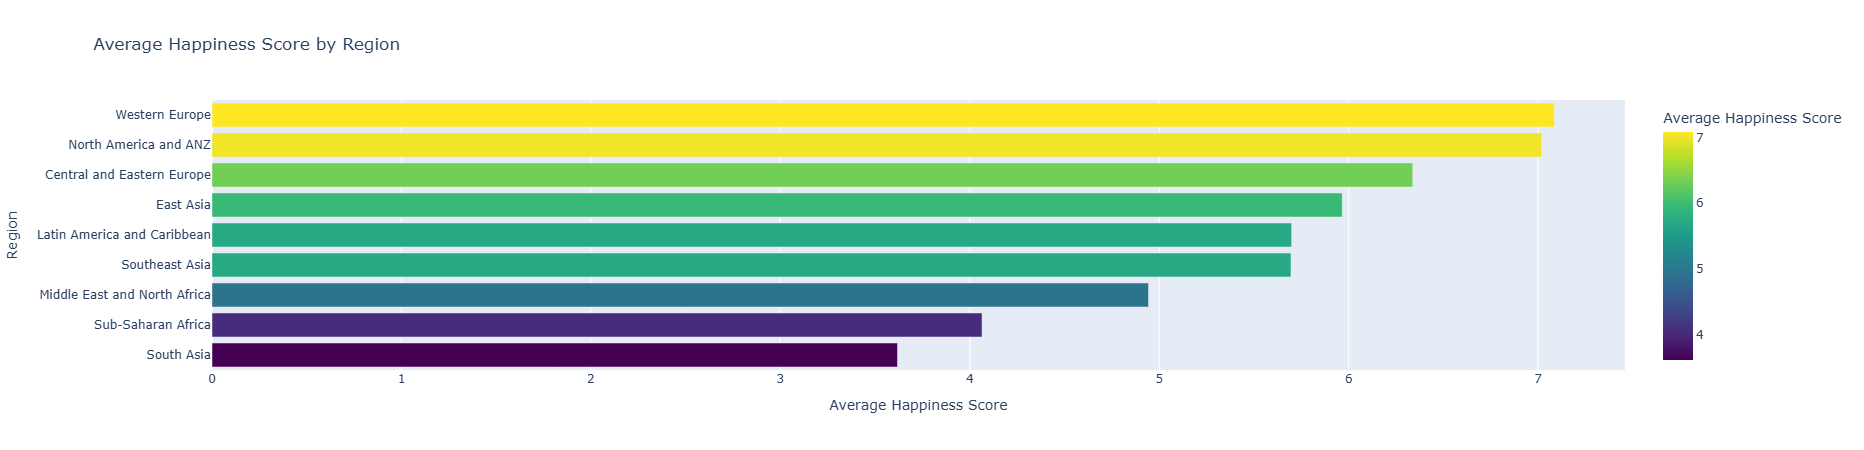

In [11]:
from IPython.display import Image, display

display(Image("Average Happiness Score.png"))

**Which region stands out and why?**

**Western Europe Leads Global Happiness, Highlighting the Link Between Strong Living Conditions and Well-Being.**

In [7]:
## Task 2 — Bottom vs. Top: A Contrast Story

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

Global average: 5.81


In [8]:
plot = px.bar(combined, x='Happiness_Score', y='Country', orientation='h',
              color='Group', color_discrete_map={'Top 8':'green','Bottom 8':'red'},
              title='Happiness Score: Bottom 8 vs Top 8 Countries',
                labels={'Happiness_Score':'Happiness Score', 'Country':'Country'},
                text='Happiness_Score')
plot.show()

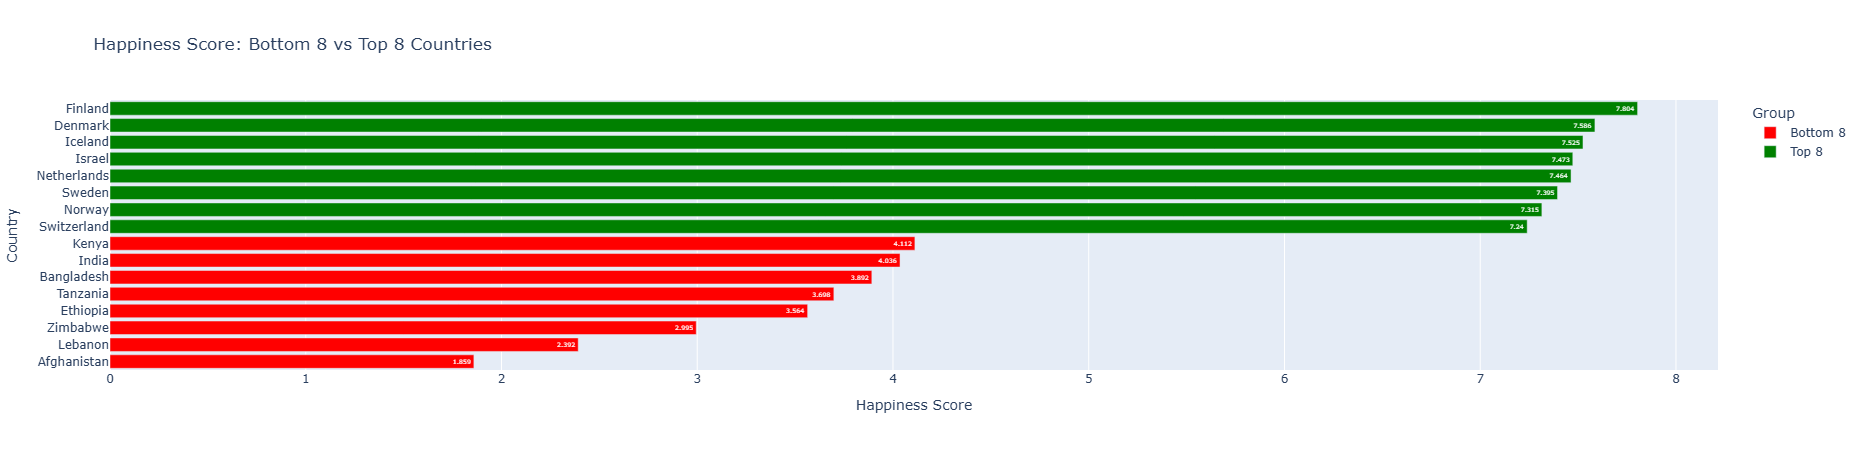

In [13]:
from IPython.display import Image, display

display(Image("Bottom 8 vs Top 8.png"))

In [9]:
#Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.
plot = px.bar(df[df['Region'].isin(df['Region'].value_counts().nlargest(5).index)],
              x='Region', y=['GDP','Freedom'], barmode='group',
                title='GDP and Freedom Comparison Across Top 5 Most Populated Regions',
                    labels={'value':'Score', 'Region':'Region'},
                    color_discrete_map={'GDP':'blue','Freedom':'orange'})
plot.show()

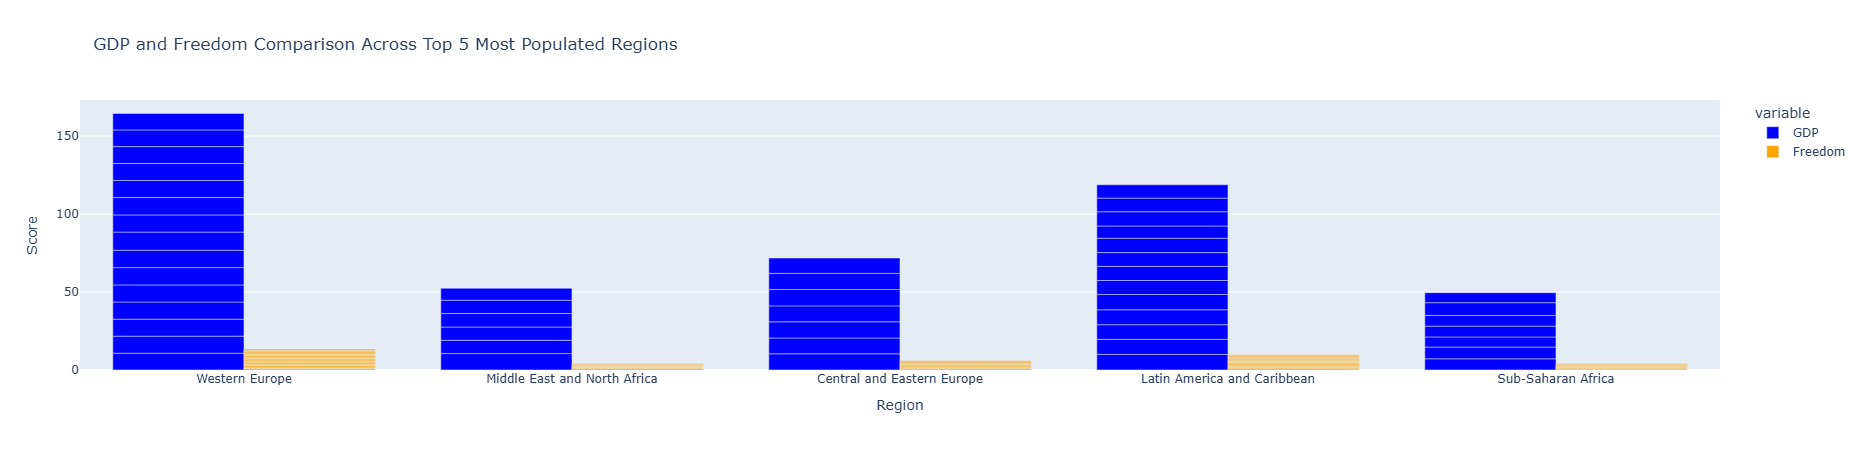

In [14]:
from IPython.display import Image, display

display(Image("GDP and Freedom Comparisons.png"))

**Insight title**

**Western Europe Shows the Highest Average GDP and Freedom Among Selected Regions.**